In [1]:
import os
import sys
sys.path.append('..')
import numpy as np
import shutil
import pandas as pd
import warnings
import scipy.stats as st

%matplotlib inline

import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

print(pd.__version__)

1.5.3


In [2]:
from scipy import interpolate

from scipy.interpolate import make_interp_spline

df = pd.read_excel('Scanner_OD.xlsx', skiprows=1, usecols='A,B',  header = None,  engine='openpyxl', sheet_name="CFU Calibration")

pxtoCFUs=df.to_numpy(copy=True)[:8,:]

pxtoCFUs=pxtoCFUs[np.argsort(pxtoCFUs[:,0]),:]

print(pxtoCFUs)
print(pxtoCFUs[0,:])

#f = interpolate.interp1d(pxtoCFUs[:,0], pxtoCFUs[:,1])
f = make_interp_spline(pxtoCFUs[:,0], pxtoCFUs[:,1], k=3)


no_bactcontrol= np.amax(pxtoCFUs[:,0])

maxbacts_convert=np.amin(pxtoCFUs[:,0]) #min intensity

[[116.158 4900000000]
 [160.407 2450000000]
 [195.153 1230000000]
 [208.473 817000000]
 [225.232 490000000]
 [243.437 49000000]
 [245.546 4900000]
 [248.263 0]]
[116.158 4900000000]


[116.158 117.158 118.158 119.158 120.158 121.158 122.158 123.158 124.158
 125.158 126.158 127.158 128.158 129.158 130.158 131.158 132.158 133.158
 134.158 135.158 136.158 137.158 138.158 139.158 140.158 141.158 142.158
 143.158 144.158 145.158 146.158 147.158 148.158 149.158 150.158 151.158
 152.158 153.158 154.158 155.158 156.158 157.158 158.158 159.158 160.158
 161.158 162.158 163.158 164.158 165.158 166.158 167.158 168.158 169.158
 170.158 171.158 172.158 173.158 174.158 175.158 176.158 177.158 178.158
 179.158 180.158 181.158 182.158 183.158 184.158 185.158 186.158 187.158
 188.158 189.158 190.158 191.158 192.158 193.158 194.158 195.158 196.158
 197.158 198.158 199.158 200.158 201.158 202.158 203.158 204.158 205.158
 206.158 207.158 208.158 209.158 210.158 211.158 212.158 213.158 214.158
 215.158 216.158 217.158 218.158 219.158 220.158 221.158 222.158 223.158
 224.158 225.158 226.158 227.158 228.158 229.158 230.158 231.158 232.158
 233.158 234.158 235.158 236.158 237.158 238.158 23

/var/folders/5b/7gmk2zpj2s186j6rvkm7z_rc0000gn/T/ipykernel_4139/673809298.py:15: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ymin=0)#, ymax = 1.5*K_bact


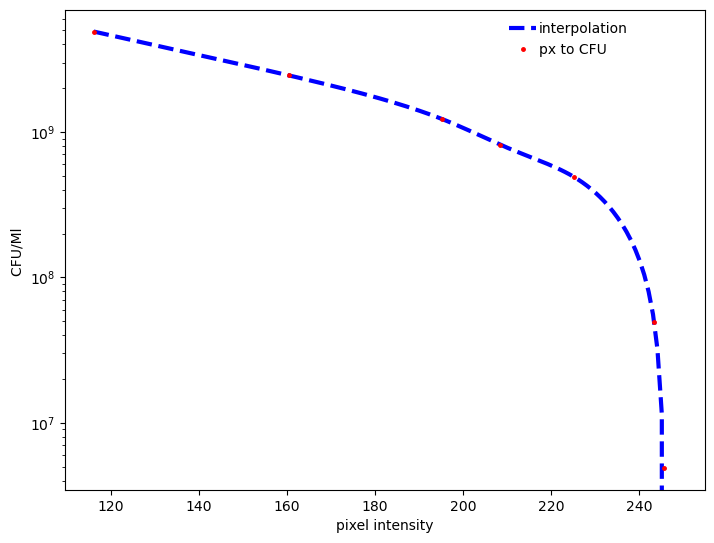

In [3]:


fig = plt.figure()
ax=fig.add_axes([0,0,1,1])

xnew = np.arange(np.amin(pxtoCFUs[:,0]),np.amax(pxtoCFUs[:,0]), 1)
ynew = f(xnew)
print(xnew)

    
ax.plot(xnew, ynew , linestyle='--',  linewidth='3', color='b', label='interpolation')
ax.plot(pxtoCFUs[:,0], pxtoCFUs[:,1] , linestyle='', marker='.', markersize='5', color='r', label='px to CFU')

ax.set_xlabel('pixel intensity')
ax.set_ylabel('CFU/Ml ')
ax.set_yscale('log')
ax.set_ylim(ymin=0)#, ymax = 1.5*K_bact
#ax.xaxis.labelpad = axis_labelpad
#ax.yaxis.labelpad = axis_labelpad
ax.legend(frameon=False, ncol=1, columnspacing=0.5, handletextpad=0.2,
    loc='upper right', bbox_to_anchor=(.9, 1.))


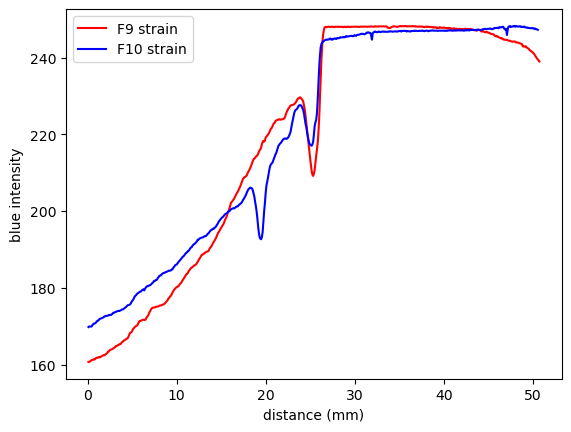

In [4]:
# Read CSV files
s09 = pd.read_csv("Intensity_F9F10/07Strain09Profile.csv", header=1).values
s10 = pd.read_csv("Intensity_F9F10/07Strain10Profile.csv", header=1).values

# Convert inch values to millimeters
inch_to_mm = 25.4
s09[:, 0] = s09[:, 0].astype(float) * inch_to_mm
s10[:, 0] = s10[:, 0].astype(float) * inch_to_mm

# Calculate max values
s09max = np.max(s09[:, 1])
s10max = np.max(s10[:, 1])

# Calculate min values
s09min = np.min(s09[:, 1])
s10min = np.min(s10[:, 1])


# renormalize intensity signal based on control

s09[:, 1]= s09min + (s09[:, 1] - s09min)*(no_bactcontrol - s09min)/(s09max -s09min)
s10[:, 1]= s10min + (s10[:, 1] - s10min)*(no_bactcontrol - s10min)/(s10max -s10min)


# Plotting
plt.figure(1)
plt.plot(s09[:, 0], s09[:, 1], 'r', label='F9 strain')
plt.plot(s10[:, 0], s10[:, 1], 'b', label='F10 strain')
plt.legend()
plt.xlabel('distance (mm)')
plt.ylabel('blue intensity')

plt.savefig('radial_intens_F9_F10.pdf')


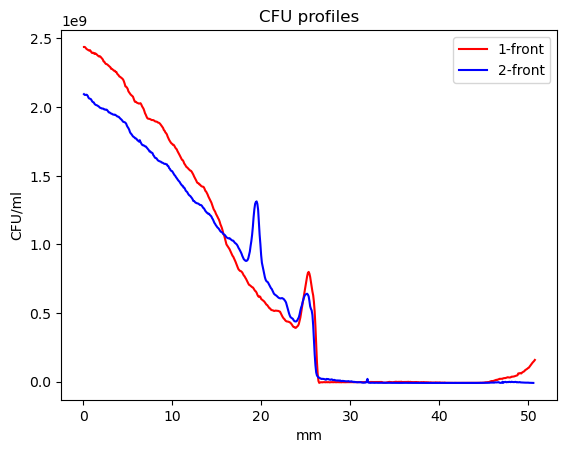

In [5]:
# correct for CFU calibration

xnew = s09[:, 1]
CFUs09 = f(xnew)
xnew = s10[:, 1]
CFUs10 = f(xnew)

plt.figure(1)
plt.plot(s09[:, 0], CFUs09, 'r', label='1-front')
plt.plot(s10[:, 0], CFUs10, 'b', label='2-front')
ax.set_ylim(ymin=1e6)#, ymax = 1.5*K_bact

plt.legend()
plt.xlabel('mm')
plt.ylabel('CFU/ml')
plt.title('CFU profiles')
ax.set_yscale('log')



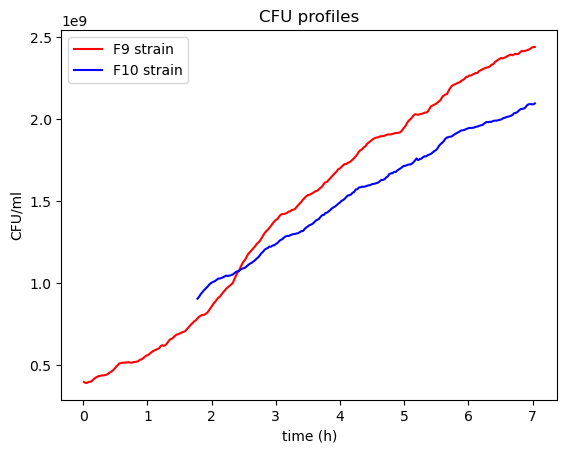

In [6]:
# show time series, cleaning bumps, in frame of reference of wave u=x-vt

v=3.4 #mm/hr

#x=s09[np.argmax(CFUs09<5e8), 0]
x=24


time09= (x - s09[:, 0] )/v
time10= (x - s10[:, 0] )/v


# clean trajectory before last front to remove transport
lower_bound = x

# Create a boolean mask for elements within the range
mask09 = (s09[:, 0] < lower_bound) 
mask10 = (s10[:, 0] < 18) 

# Filter the array to remove elements within the specified range
time09 = time09[mask09]
CFUs09_filter = CFUs09[mask09]
time10 = time10[mask10]
CFUs10_filter = CFUs10[mask10]

arr1inds = time09.argsort()
time09 =time09[arr1inds]
CFUs09_filter =CFUs09_filter[arr1inds]
arr1inds = time10.argsort()
time10 =time10[arr1inds]
CFUs10_filter =CFUs10_filter[arr1inds]

plt.figure(1)
plt.plot(time09, CFUs09_filter, 'r', label='F9 strain')
plt.plot(time10, CFUs10_filter, 'b', label='F10 strain')
ax.set_ylim(ymin=1e6)#, ymax = 1.5*K_bact

plt.legend()
plt.xlabel('time (h)')
plt.ylabel('CFU/ml')
plt.title('CFU profiles')
ax.set_yscale('log')

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 71
    # data points      = 283
    # variables        = 3
    chi-square         = 5.7624e+17
    reduced chi-square = 2.0580e+15
    Akaike info crit   = 9981.70786
    Bayesian info crit = 9992.64420
[[Variables]]
    R0:  2.1397e+09 +/- 28805698.7 (1.35%) (init = 2.5e+09)
    S0:  3.978408e+08 (fixed)
    r:   1.52625979 +/- 0.27260597 (17.86%) (init = 1)
    K:   5.0000e+09 +/- 83846948.9 (1.68%) (init = 2.5e+09)
[[Correlations]] (unreported correlations are < 0.100)
    C(r, K)  = -0.9992
    C(R0, K) = -0.9311
    C(R0, r) = +0.9163


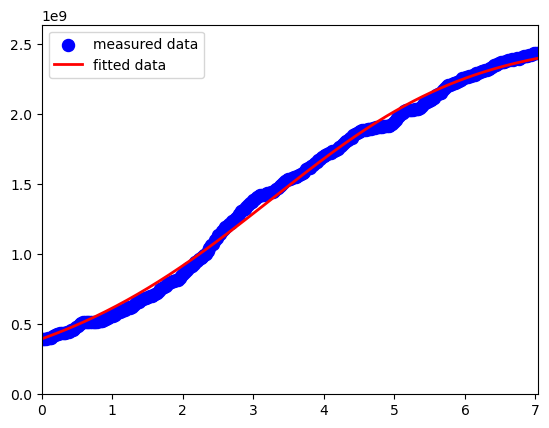

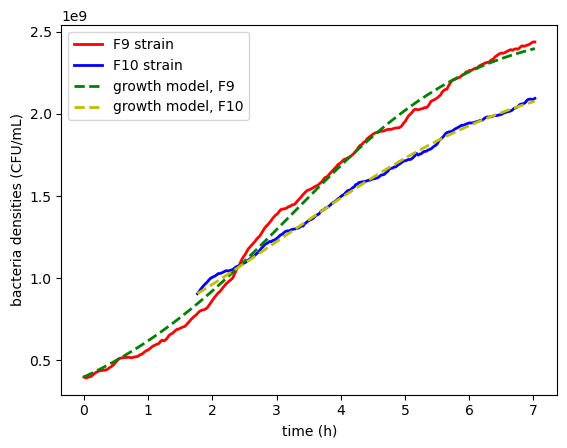

In [11]:
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from lmfit import minimize, Parameters, Parameter, report_fit


def bact_growth(t,y, paras):
    """
    Differential equations
    """

    R = y[0]
    S = y[1]

    r = paras['r'].value
    K = paras['K'].value

    # the model equations
    dRdt = -r * S*(R/(R+K))
    dSdt = r * S*(R/(R+K))
    
    return [dRdt, dSdt]


def g(t_data, IC, paras):
    """
    Solution to the ODE x'(t) = f(t,x,k) with initial condition x(0) = x0
    """
    solution = solve_ivp(bact_growth, [t_data[0], t_data[-1]], IC, args=(paras,), t_eval=t_data, method='RK45', dense_output=False,  max_step=0.01, rtol= 1e-8, atol=1e-8)

    return solution


def residual(paras, t, data):

    """
    compute the residual between actual data and fitted data
    """

    x0 = paras['R0'].value, paras['S0'].value
    model = g(t, x0, paras)
    
    #print(model.y[1, :])

    #only have data for one of the variables
    S_model = model.y[1, :]
    return (S_model - data).ravel()


# initial conditions
R0 = 2.5e9
S0 = CFUs09_filter[0]
#S0 = 0
y0 = [R0, S0]

# measured data
t_measured = time09
y_measured = CFUs09_filter

plt.figure()
plt.scatter(t_measured, y_measured, marker='o', color='b', label='measured data', s=75)

params = Parameters()
params.add('R0', value=R0, min=0.01*R0, max=2*R0)#, vary=False

params.add('S0', value=S0, vary=False)

params.add('r', value=1, min=0.01, max=20.)
params.add('K', value=R0, min=0.01*R0, max=2*R0)

# fit model
result = minimize(residual, params, args=(t_measured, y_measured), method='leastsq')  # leastsq nelder
# check results of the fit
y0_fitted=result.params['R0'].value, result.params['S0'].value
data_fitted = g(t_measured, y0_fitted, result.params)
S_fitted = data_fitted.y[1, :]


# plot fitted data
plt.plot(t_measured, S_fitted, '-', linewidth=2, color='red', label='fitted data')
plt.legend()
plt.xlim([0, max(t_measured)])
plt.ylim([0, 1.1 * max(S_fitted)])
# display fitted statistics
report_fit(result)

plt.show()



plt.figure(1)
plt.plot(time09 - time09[0], CFUs09_filter, 'r', linewidth=2, label='F9 strain')
plt.plot(time10 - time09[0], CFUs10_filter, 'b', linewidth=2, label='F10 strain')
plt.plot(t_measured - time09[0], S_fitted, '--', linewidth=2, color='g', label='growth model, F9')

S0_avg=np.mean([CFUs09_filter[0]])

y0 = [2.5e9 - S0_avg, S0_avg]

params = Parameters()


params.add('r', value=1.6, vary=False)
params.add('K', value=5e9, vary=False)
model_final = g(t_measured - t_measured[0], y0, params)
S_final = model_final.y[1, :]


# plot fitted data


# initial conditions
R0 = 2.5e9
S0 = CFUs10_filter[0]
#S0 = 0
y0 = [R0, S0]

# measured data
t_measured = time10
y_measured = CFUs10_filter

# set parameters including bounds; you can also fix parameters (use vary=False)
params = Parameters()
params.add('R0', value=R0, min=0.01*R0, max=2*R0)#, vary=False

params.add('S0', value=S0, vary=False)

params.add('r', value=1, min=0.01, max=20.)
params.add('K', value=R0, min=0.01*R0, max=2*R0)

# fit model
result = minimize(residual, params, args=(t_measured, y_measured), method='leastsq', scale_covar=True)  # leastsq nelder
# check results of the fit
y0_fitted=result.params['R0'].value, result.params['S0'].value
data_fitted = g(t_measured, y0_fitted, result.params)
S_fitted = data_fitted.y[1, :]
plt.plot(t_measured - time09[0], S_fitted, '--', linewidth=2, color='y', label='growth model, F10')

plt.legend()
plt.xlabel('time (h)')
plt.ylabel('bacteria densities (CFU/mL)')
plt.savefig('growth_fitting_F9.pdf')


[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 88
    # data points      = 212
    # variables        = 3
    chi-square         = 6.6118e+16
    reduced chi-square = 3.1635e+14
    Akaike info crit   = 7081.20901
    Bayesian info crit = 7091.27877
[[Variables]]
    R0:  1.4228e+09 +/- 39632064.2 (2.79%) (init = 2.5e+09)
    S0:  9.050819e+08 (fixed)
    r:   1.20783255 +/- 0.42602551 (35.27%) (init = 1)
    K:   5.0000e+09 +/- 77102202.9 (1.54%) (init = 2.5e+09)
[[Correlations]] (unreported correlations are < 0.100)
    C(r, K)  = -0.9996
    C(R0, K) = -0.9716
    C(R0, r) = +0.9651


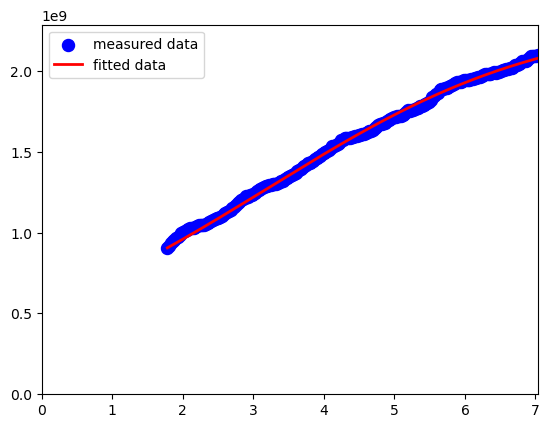

In [8]:

# initial conditions
R0 = 2.5e9
S0 = CFUs10_filter[0]
#S0 = 0
y0 = [R0, S0]

# measured data
t_measured = time10
y_measured = CFUs10_filter

plt.figure()
plt.scatter(t_measured, y_measured, marker='o', color='b', label='measured data', s=75)

# set parameters including bounds; you can also fix parameters (use vary=False)
params = Parameters()
params.add('R0', value=R0, min=0.01*R0, max=2*R0)#, vary=False

params.add('S0', value=S0, vary=False)

params.add('r', value=1, min=0.01, max=20.)
params.add('K', value=R0, min=0.01*R0, max=2*R0)

# fit model
result = minimize(residual, params, args=(t_measured, y_measured), method='leastsq', scale_covar=True)  # leastsq nelder
# check results of the fit
y0_fitted=result.params['R0'].value, result.params['S0'].value
data_fitted = g(t_measured, y0_fitted, result.params)
S_fitted = data_fitted.y[1, :]


# plot fitted data
plt.plot(t_measured, S_fitted, '-', linewidth=2, color='red', label='fitted data')
plt.legend()
plt.xlim([0, max(t_measured)])
plt.ylim([0, 1.1 * max(S_fitted)])
# display fitted statistics
report_fit(result)

plt.show()

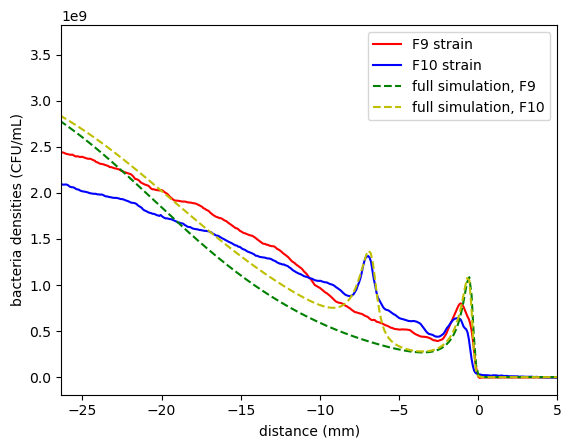

In [10]:
file_in_frames = "pop_densities_justbact_diag_22_F10.dat" # K1=1.5, ap 100 R0 2500, mu3 BEST


data_space = np.loadtxt(file_in_frames)

xsim   = data_space[:,0]
S   = data_space[:,1]
E   = data_space[:,2]

x1=s09[np.argmax(CFUs09<5e7), 0]

x2=xsim[np.argmax(S<5e7)]

file_in_frames_9 = "pop_densities_justbact_diag_36_F9.dat" # K1=1.5, ap 100 R0 2500, mu3 BEST


data_space_9 = np.loadtxt(file_in_frames_9)

xsim_9   = data_space_9[:,0]
S_9   = data_space_9[:,1]

x2_9=xsim_9[np.argmax(S_9<5e7)]




fig = plt.figure(1)
plt.plot(s09[:, 0]-x1, CFUs09, 'r', label='F9 strain')
plt.plot(s10[:, 0]-x1, CFUs10, 'b', label='F10 strain')
plt.plot(xsim_9-x2_9, S_9, 'g', linestyle='--', label='full simulation, F9')


plt.plot(xsim-x2, S, 'y', linestyle='--', label='full simulation, F10')

plt.xlim(xmin=np.amin(s09[:, 0]-x1), xmax=5)#, ymax = 1.5*K_bact

plt.legend()
plt.xlabel('distance (mm)')
plt.ylabel('bacteria densities (CFU/mL)')
plt.savefig('profile2front_F9.pdf')

